In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

In [3]:
df = pd.read_csv("data/har_features.csv")

META_COLS = ["session_id", "sub_session_id", "window_start_idx",
             "label", "is_walking", "is_scrolling"]
feature_cols = [c for c in df.columns if c not in META_COLS]

print(f"{len(feature_cols)} features | {len(df)} windows | "
      f"{df['sub_session_id'].nunique()} sub-sessions")
print()
print(df.groupby(["is_walking", "is_scrolling"]).size().rename("windows"))

116 features | 1250 windows | 32 sub-sessions

is_walking  is_scrolling
0           0               227
            1               293
1           0               387
            1               343
Name: windows, dtype: int64


In [4]:
def evaluate(clf, X, y, groups, n_splits, labels):
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    y_true_all, y_pred_all, fold_f1s = [], [], []

    for train_idx, test_idx in sgkf.split(X, y, groups=groups):
        clf.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = clf.predict(X.iloc[test_idx])
        y_true_all.extend(y.iloc[test_idx])
        y_pred_all.extend(y_pred)
        fold_f1s.append(
            f1_score(y.iloc[test_idx], y_pred, average="macro", zero_division=0)
        )

    print(f"F1 macro: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}  ({n_splits} folds)")
    print()
    print(classification_report(y_true_all, y_pred_all,
                                target_names=labels, zero_division=0))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true_all, y_pred_all), display_labels=labels
    ).plot(cmap="Blues")
    plt.tight_layout()
    plt.show()

## Step 1 — Walking detector
Trained on all 8 sessions (32 sub-sessions). Should be easy: walking has a strong 1–3 Hz IMU signature.

F1 macro: 1.000 ± 0.000  (5 folds)

              precision    recall  f1-score   support

     Sitting       1.00      1.00      1.00       520
     Walking       1.00      1.00      1.00       730

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250



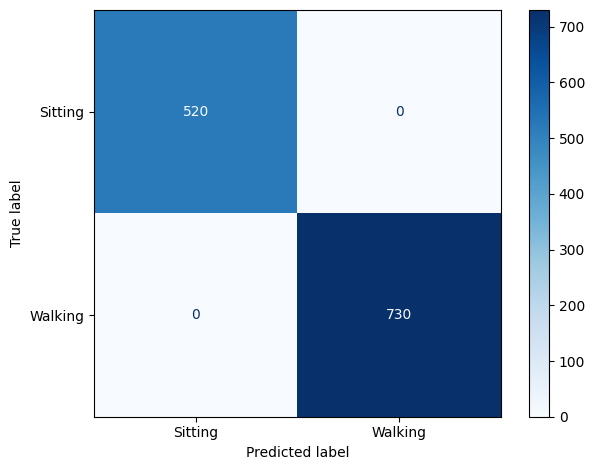

In [5]:
clf_walk = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)

evaluate(
    clf_walk,
    df[feature_cols], df["is_walking"], df["sub_session_id"],
    n_splits=5,
    labels=["Sitting", "Walking"]
)

## Step 2 — Scrolling detector (conditioned on posture)
Two separate classifiers: one for the walking context, one for sitting.
Each uses only the 4 sessions matching that posture (16 sub-sessions each).

> **Caveat**: only 1 scrolling session per context — CV scores are optimistic
> since all scrolling chunks come from the same recording.

── Step 2a: Scrolling Detector (Walking context) ─────────────────
730 windows | 4 sessions | 16 sub-sessions

F1 macro: 0.843 ± 0.271  (4 folds)

               precision    recall  f1-score   support

Not Scrolling       0.82      1.00      0.90       387
    Scrolling       1.00      0.76      0.86       343

     accuracy                           0.89       730
    macro avg       0.91      0.88      0.88       730
 weighted avg       0.91      0.89      0.88       730



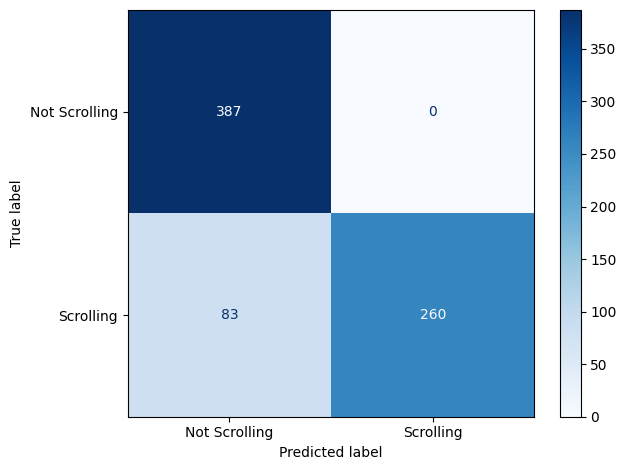

In [6]:
walk_df = df[df["is_walking"] == 1].copy()

print("── Step 2a: Scrolling Detector (Walking context) ─────────────────")
print(f"{len(walk_df)} windows | "
      f"{walk_df['session_id'].nunique()} sessions | "
      f"{walk_df['sub_session_id'].nunique()} sub-sessions")
print()

clf_scroll_walk = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)
evaluate(
    clf_scroll_walk,
    walk_df[feature_cols], walk_df["is_scrolling"], walk_df["sub_session_id"],
    n_splits=4,
    labels=["Not Scrolling", "Scrolling"]
)

── Step 2b: Scrolling Detector (Sitting context) ─────────────────
520 windows | 4 sessions | 16 sub-sessions

F1 macro: 1.000 ± 0.000  (4 folds)

               precision    recall  f1-score   support

Not Scrolling       1.00      1.00      1.00       227
    Scrolling       1.00      1.00      1.00       293

     accuracy                           1.00       520
    macro avg       1.00      1.00      1.00       520
 weighted avg       1.00      1.00      1.00       520



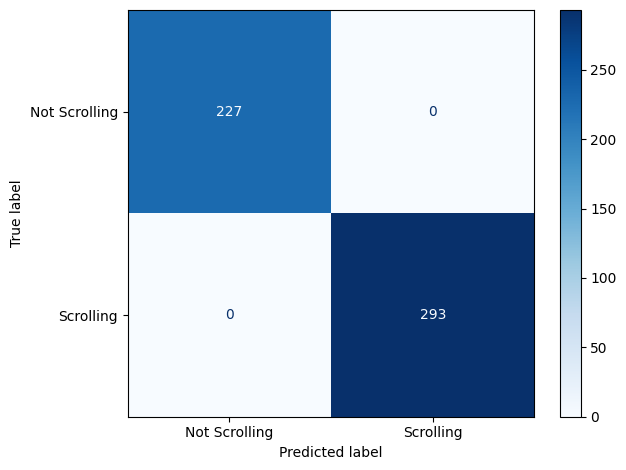

In [7]:
sit_df = df[df["is_walking"] == 0].copy()

print("── Step 2b: Scrolling Detector (Sitting context) ─────────────────")
print(f"{len(sit_df)} windows | "
      f"{sit_df['session_id'].nunique()} sessions | "
      f"{sit_df['sub_session_id'].nunique()} sub-sessions")
print()

clf_scroll_sit = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)
evaluate(
    clf_scroll_sit,
    sit_df[feature_cols], sit_df["is_scrolling"], sit_df["sub_session_id"],
    n_splits=4,
    labels=["Not Scrolling", "Scrolling"]
)

## Feature importance
Refit on the full dataset to inspect which features drive each classifier.

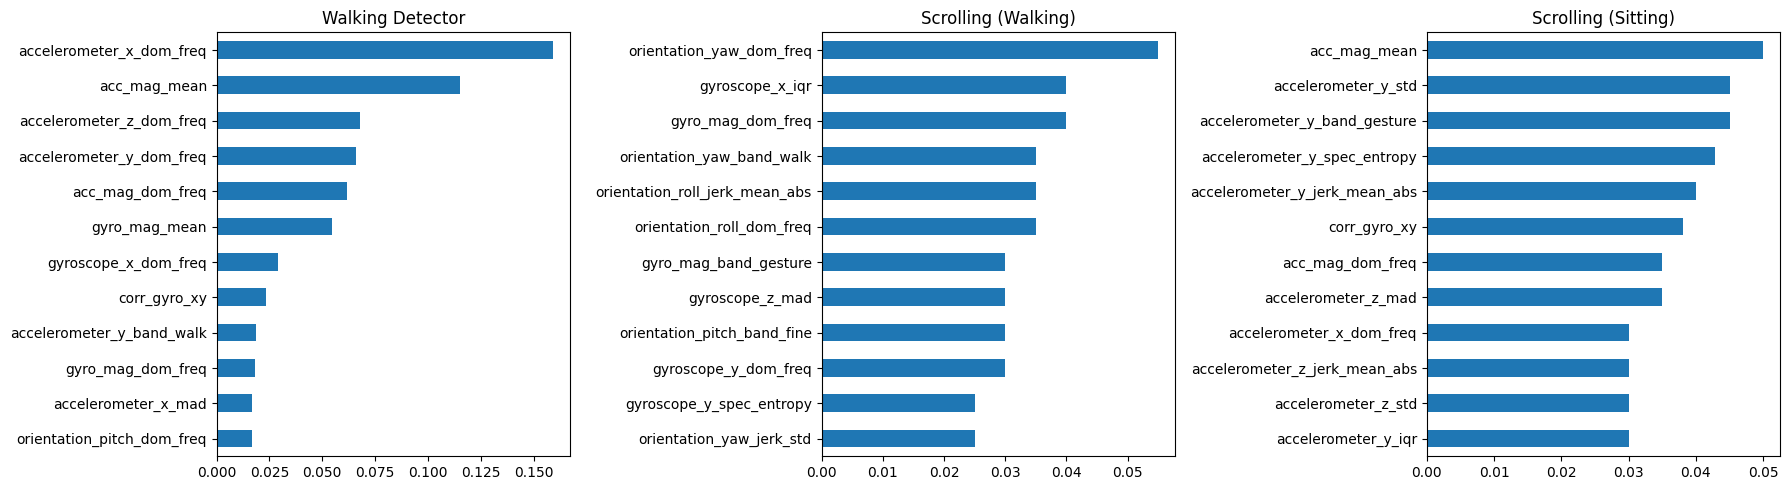

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (df,      df["is_walking"],   "Walking Detector"),
    (walk_df, walk_df["is_scrolling"], "Scrolling (Walking)"),
    (sit_df,  sit_df["is_scrolling"],  "Scrolling (Sitting)"),
]

for ax, (subset, target, title) in zip(axes, configs):
    clf = RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    )
    clf.fit(subset[feature_cols], target)
    pd.Series(clf.feature_importances_, index=feature_cols) \
      .nlargest(12).sort_values() \
      .plot(kind="barh", ax=ax, title=title)

plt.tight_layout()
plt.show()